<a href="https://colab.research.google.com/github/lohithanarni-commits/Text-topic-extractor-/blob/main/Text_topic_extractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
documents = [
    "cat dog animal",
    "cat dog pet",
    "car bus vehicle",
    "car bus road"
]

print("Number of documents:", len(documents))
print("Documents:")
for i, doc in enumerate(documents):
    print(i + 1, ":", doc)

Number of documents: 4
Documents:
1 : cat dog animal
2 : cat dog pet
3 : car bus vehicle
4 : car bus road


In [ ]:
words = sorted(set(word for doc in documents for word in doc.split()))

matrix = np.array([
    [doc.split().count(word) for doc in documents]
    for word in words
])

print("Words:", words)
print("\nWord-Document Matrix:")
print(matrix)

Words: ['animal', 'bus', 'car', 'cat', 'dog', 'pet', 'road', 'vehicle']

Word-Document Matrix:
[[1 0 0 0]
 [0 0 1 1]
 [0 0 1 1]
 [1 1 0 0]
 [1 1 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]


In [ ]:
U, S, VT = np.linalg.svd(matrix, full_matrices=False)

print("Singular values:")
print(S)

Singular values:
[2.23606798 2.23606798 1.         1.        ]


In [ ]:
print("Original matrix A:")
print(matrix)

print("\nU:")
print(np.round(U, 2))

print("\nSingular values Σ:")
print(np.round(S, 2))

print("\nVT:")
print(np.round(VT, 2))

Original matrix A:
[[1 0 0 0]
 [0 0 1 1]
 [0 0 1 1]
 [1 1 0 0]
 [1 1 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]

U:
[[ 0.   -0.32  0.71 -0.  ]
 [-0.63  0.    0.   -0.  ]
 [-0.63  0.    0.    0.  ]
 [-0.   -0.63 -0.    0.  ]
 [ 0.   -0.63 -0.   -0.  ]
 [ 0.   -0.32 -0.71 -0.  ]
 [-0.32  0.    0.    0.71]
 [-0.32  0.    0.   -0.71]]

Singular values Σ:
[2.24 2.24 1.   1.  ]

VT:
[[-0.   -0.   -0.71 -0.71]
 [-0.71 -0.71 -0.   -0.  ]
 [ 0.71 -0.71 -0.   -0.  ]
 [ 0.    0.   -0.71  0.71]]


In [ ]:
k = 2

U_k = U[:, :k]
S_k = S[:k]
VT_k = VT[:k, :]

print("Top", k, "singular values:")
print(np.round(S_k, 2))

Top 2 singular values:
[2.24 2.24]


In [ ]:
A_approx = U_k @ np.diag(S_k) @ VT_k

print("Approximate matrix using", k, "topics:")
print(np.round(A_approx, 2))

Approximate matrix using 2 topics:
[[ 0.5  0.5 -0.  -0. ]
 [ 0.   0.   1.   1. ]
 [ 0.   0.   1.   1. ]
 [ 1.   1.   0.   0. ]
 [ 1.   1.  -0.  -0. ]
 [ 0.5  0.5 -0.  -0. ]
 [ 0.   0.   0.5  0.5]
 [ 0.   0.   0.5  0.5]]


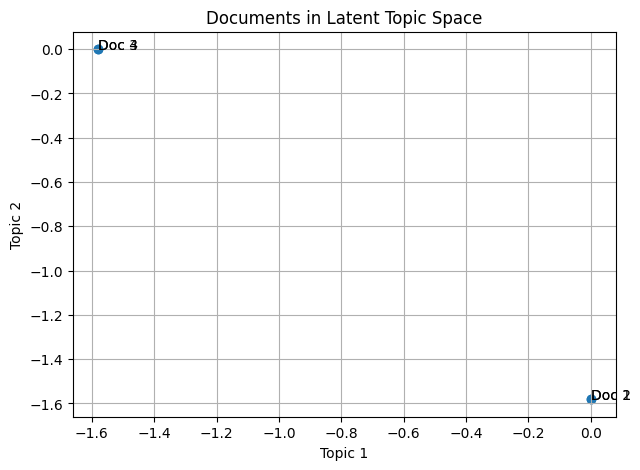

In [ ]:
document_coordinates = VT_k.T @ np.diag(S_k)

plt.figure(figsize=(7, 5))

plt.scatter(
    document_coordinates[:, 0],
    document_coordinates[:, 1]
)

for i in range(len(documents)):
    plt.text(
        document_coordinates[i, 0],
        document_coordinates[i, 1],
        f"Doc {i+1}"
    )

plt.xlabel("Topic 1")
plt.ylabel("Topic 2")
plt.title("Documents in Latent Topic Space")
plt.grid()
plt.show()